# XGBoost Immunogenicity Predictor

In [13]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import joblib
from sklearn.metrics import average_precision_score
from sklearn.metrics import RocCurveDisplay

In [ ]:
df = pd.read_csv("../data/features/processed_data_with_position_specific_features.csv")

#Drop non feature columns
DROP_COLS = ["peptide", "hla_sequence", "index"]
TARGET_COL = "Label"

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

#Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]
print(f"Encoding categorical columns: {cat_cols}")

df = pd.get_dummies(df, columns=cat_cols) 

# Split x and y values
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

print(df.columns.tolist()) #check what columns exist

print(f"Features: {X.shape}, Classes: {dict(zip(*np.unique(y, return_counts=True)))}")



train_idx = np.load("../data/splits/train_idx.npy")
val_idx = np.load("../data/splits/val_idx.npy")
test_idx = np.load("../data/splits/test_idx.npy")

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_val, y_val     = X.iloc[val_idx], y[val_idx]
X_test, y_test   = X.iloc[test_idx], y[test_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Encoding categorical columns: ['HLA']
['Label', 'PeptidePos_p1_f1', 'PeptidePos_p1_f2', 'PeptidePos_p1_f3', 'PeptidePos_p1_f4', 'PeptidePos_p1_f5', 'PeptidePos_p1_f6', 'PeptidePos_p1_f7', 'PeptidePos_p1_f8', 'PeptidePos_p1_f9', 'PeptidePos_p1_f10', 'PeptidePos_p1_f11', 'PeptidePos_p1_f12', 'PeptidePos_p1_f13', 'PeptidePos_p1_f14', 'PeptidePos_p1_f15', 'PeptidePos_p1_f16', 'PeptidePos_p1_f17', 'PeptidePos_p1_f18', 'PeptidePos_p2_f1', 'PeptidePos_p2_f2', 'PeptidePos_p2_f3', 'PeptidePos_p2_f4', 'PeptidePos_p2_f5', 'PeptidePos_p2_f6', 'PeptidePos_p2_f7', 'PeptidePos_p2_f8', 'PeptidePos_p2_f9', 'PeptidePos_p2_f10', 'PeptidePos_p2_f11', 'PeptidePos_p2_f12', 'PeptidePos_p2_f13', 'PeptidePos_p2_f14', 'PeptidePos_p2_f15', 'PeptidePos_p2_f16', 'PeptidePos_p2_f17', 'PeptidePos_p2_f18', 'PeptidePos_p3_f1', 'PeptidePos_p3_f2', 'PeptidePos_p3_f3', 'PeptidePos_p3_f4', 'PeptidePos_p3_f5', 'PeptidePos_p3_f6', 'PeptidePos_p3_f7', 'PeptidePos_p3_f8', 'PeptidePos_p3_f9', 'PeptidePos_p3_f10', 'PeptidePos_p

In [6]:
model = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

model.fit(X_train, y_train)
print("Model trained!!")

Model trained!!


In [7]:
# predict on test set
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]


test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_auc, 4))

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7923
Test ROC-AUC: 0.872

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       991
           1       0.75      0.82      0.78       824

    accuracy                           0.79      1815
   macro avg       0.79      0.79      0.79      1815
weighted avg       0.80      0.79      0.79      1815



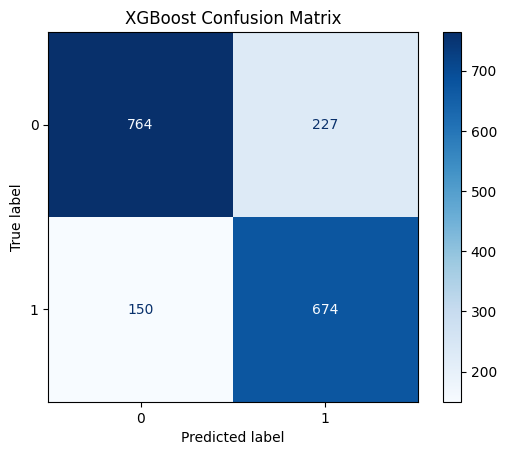

In [8]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [11]:
test_auprc = average_precision_score(y_test, y_test_prob)
print("Test AUPRC:", round(test_auprc, 4))

Test AUPRC: 0.8167


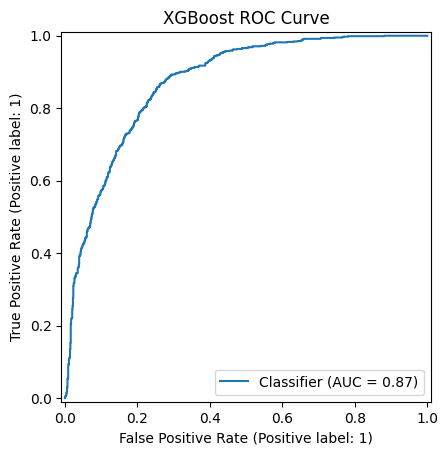

In [14]:
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("XGBoost ROC Curve")
plt.show()

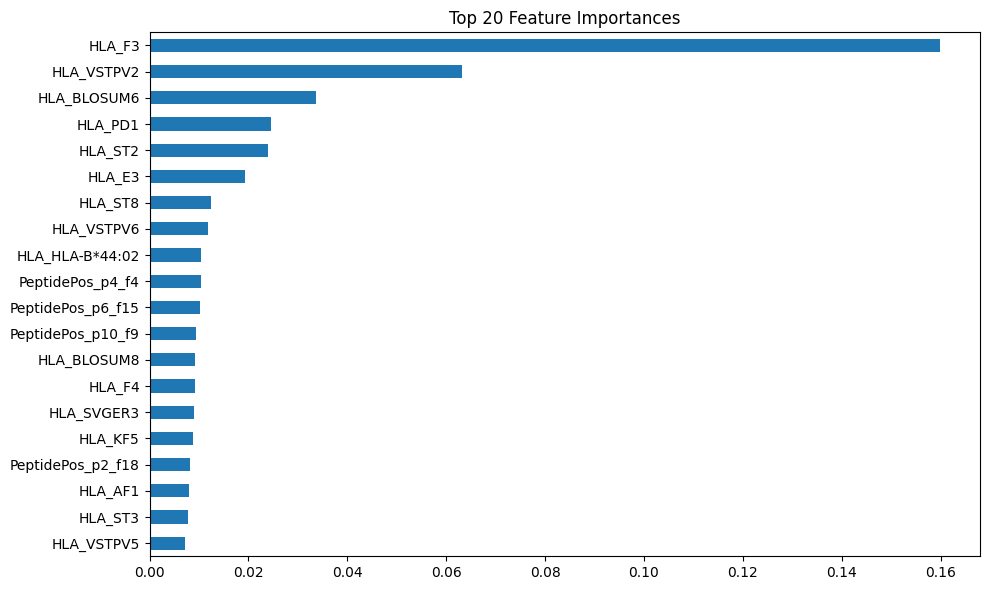

In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(10, 6))

plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [17]:
joblib.dump(
    {
        "model": model,
        "features": X.columns.tolist(),
        "params": model.get_params(),
        "model_name": "XGBoost",
        "version": "v1",
        "notes": " position specific features local and global HLA"
    },
    "../models/xgboost_v1.pkl"
)

print("saved")

saved


## XGBoost Random Search

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from scipy.stats import randint, uniform
import os

In [21]:
# parameter space
param_dist = {
    "n_estimators": randint(300, 1000),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.09),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 2)
}


In [22]:
n_trials = 30
start_v = 2

results = []

for i in range(n_trials):
    version = f"v{start_v + i}"
    
    # sample from param_dist
    params = {k: v.rvs() for k, v in param_dist.items()}
    
    # add fixed params
    params.update({
        "random_state": 42,
        "eval_metric": "logloss",
        "use_label_encoder": False
    })

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    # validation performance
    y_val_prob = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, y_val_prob)

    print(f"{version} | AUC: {round(val_auc,4)}")

    # save model
    joblib.dump(
        {
            "model": model,
            "features": X.columns.tolist(),
            "params": model.get_params(),
            "model_name": "XGBoost",
            "version": version,
            "val_auc": val_auc
        },
        f"../models/xgboost_{version}.pkl"
    )

    results.append((version, val_auc, params))

v2 | AUC: 0.8521
v3 | AUC: 0.8754
v4 | AUC: 0.8735
v5 | AUC: 0.8732
v6 | AUC: 0.8667
v7 | AUC: 0.8696
v8 | AUC: 0.8642
v9 | AUC: 0.8722
v10 | AUC: 0.8604
v11 | AUC: 0.8735
v12 | AUC: 0.8745
v13 | AUC: 0.8709
v14 | AUC: 0.8762
v15 | AUC: 0.8732
v16 | AUC: 0.8706
v17 | AUC: 0.8737
v18 | AUC: 0.877
v19 | AUC: 0.8724
v20 | AUC: 0.8687
v21 | AUC: 0.8798
v22 | AUC: 0.8694
v23 | AUC: 0.8611
v24 | AUC: 0.873
v25 | AUC: 0.8579
v26 | AUC: 0.8763
v27 | AUC: 0.8743
v28 | AUC: 0.873
v29 | AUC: 0.8742
v30 | AUC: 0.8753
v31 | AUC: 0.8631


In [23]:
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

for r in results_sorted[:5]:
    print(r)

('v21', 0.8798027338638919, {'n_estimators': 725, 'max_depth': 6, 'learning_rate': np.float64(0.08264146294604963), 'subsample': np.float64(0.9154635761846038), 'colsample_bytree': np.float64(0.7158725288236268), 'gamma': np.float64(0.5606799131586906), 'random_state': 42, 'eval_metric': 'logloss', 'use_label_encoder': False})
('v18', 0.877022305004387, {'n_estimators': 604, 'max_depth': 6, 'learning_rate': np.float64(0.018896776442692477), 'subsample': np.float64(0.7750565311372789), 'colsample_bytree': np.float64(0.894943699211018), 'gamma': np.float64(0.6351935294902544), 'random_state': 42, 'eval_metric': 'logloss', 'use_label_encoder': False})
('v26', 0.8763180579714607, {'n_estimators': 914, 'max_depth': 4, 'learning_rate': np.float64(0.04012144708761479), 'subsample': np.float64(0.9206035615058689), 'colsample_bytree': np.float64(0.7662650983616672), 'gamma': np.float64(0.36615379664856595), 'random_state': 42, 'eval_metric': 'logloss', 'use_label_encoder': False})
('v14', 0.876

In [24]:
top_versions = ["v21", "v18", "v26", "v14", "v3"]

for version in top_versions:
    obj = joblib.load(f"../models/xgboost_{version}.pkl")
    model = obj["model"]
    
    y_test_prob = model.predict_proba(X_test)[:, 1]
    y_test_pred = model.predict(X_test)
    
    test_auc = roc_auc_score(y_test, y_test_prob)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(version, "| Test AUC:", round(test_auc, 4), "| Test Acc:", round(test_acc, 4))

v21 | Test AUC: 0.884 | Test Acc: 0.8077
v18 | Test AUC: 0.8873 | Test Acc: 0.8055
v26 | Test AUC: 0.8847 | Test Acc: 0.8017
v14 | Test AUC: 0.8849 | Test Acc: 0.7983
v3 | Test AUC: 0.8851 | Test Acc: 0.7994


In [25]:
best_model_data = joblib.load("../models/xgboost_v21.pkl")
best_model = best_model_data["model"]

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8077
Test ROC-AUC: 0.884

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       991
           1       0.78      0.80      0.79       824

    accuracy                           0.81      1815
   macro avg       0.81      0.81      0.81      1815
weighted avg       0.81      0.81      0.81      1815

